# Project 1: Centrality by Position in Euro 2024 Passing Networks

**Joao De Oliveira**

## Question
Do defenders, midfielders, forwards and goalkeepers differ in how central they are in their team's passing network? And does a team's centrality pattern relate to how many chances it creates?

## Data
[StatsBomb Open Data](https://github.com/statsbomb/open-data) provides free, event-level data for every match of **UEFA Euro 2024** (51 matches), published as JSON files on GitHub. Every completed pass records the passer and the recipient.

- **Network:** one passing network per team per match
- **Node:** a player in the starting XI
- **Edge:** completed passes between two teammates (in either direction), with the number of passes being the weight
- **Categorical variable:** each player's starting position, grouped into **Goalkeeper, Defender, Midfielder, Forward**

## Hypotheses
1. Midfielders will have the highest degree centrality, because they link the defense to the attack.
2. Teams whose defenders are more central than their midfielders are stuck passing around the back, so they should create fewer chances (lower xG).

*Data: StatsBomb Open Data.*
https://github.com/hudl/open-data

## 0. Setup

In [33]:
import os, json, urllib.request
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)
pd.set_option("display.precision", 3)
print("networkx", nx.__version__)

networkx 3.7


## 1. Load the data from GitHub
The repository has a `competitions.json` index, one match list per competition and season, and one events file per match. I look up Euro 2024's IDs from the index rather than hard-coding them, then download the 51 event files in parallel. They take up about 150 MB and are cached locally, so rerunning is smooth and instant.

In [34]:
RAW = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
CACHE = "statsbomb_cache"
os.makedirs(CACHE, exist_ok=True)

def get_json(path):
    local = os.path.join(CACHE, path.replace("/", "_"))
    if not os.path.exists(local):
        urllib.request.urlretrieve(f"{RAW}/{path}", local)
    with open(local, encoding="utf-8") as f:
        return json.load(f)

comps = pd.DataFrame(get_json("competitions.json"))
euro = comps[(comps.competition_name == "UEFA Euro") & (comps.season_name == "2024")].iloc[0]
COMP_ID, SEASON_ID = int(euro.competition_id), int(euro.season_id)
print(f"UEFA Euro 2024 -> competition_id {COMP_ID}, season_id {SEASON_ID}")

matches = get_json(f"matches/{COMP_ID}/{SEASON_ID}.json")
match_ids = [m["match_id"] for m in matches]
with ThreadPoolExecutor(max_workers=8) as pool:
    events_list = list(pool.map(lambda mid: get_json(f"events/{mid}.json"), match_ids))
events = dict(zip(match_ids, events_list))

# real elapsed time since statsbomb restarts the clock at 45:00 in the second half, so 1st half stoppage
# time would overlap it. Each event gets "_t" = minutes elapsed since kickoff, using each period's real length
def clock(e):
    h, m, sec = e["timestamp"].split(":")
    return int(h) * 60 + int(m) + float(sec) / 60

for ev in events.values():
    ends = {}
    for e in ev:
        if e["type"]["name"] == "Half End":
            ends[e["period"]] = max(ends.get(e["period"], 0), clock(e))
    offset, run = {}, 0.0
    for p in sorted(ends):
        offset[p] = run
        run += ends[p]
    for e in ev:
        e["_t"] = offset.get(e["period"], run) + clock(e)

# lineup files hold each player's common name and not actual formal name
with ThreadPoolExecutor(max_workers=8) as pool:
    lineups_list = list(pool.map(lambda mid: get_json(f"lineups/{mid}.json"), match_ids))
DISPLAY_NAME = {p["player_id"]: p["player_nickname"] or p["player_name"]
                for lu in lineups_list for team in lu for p in team["lineup"]}

print(f"Matches: {len(matches)} | total events: {sum(len(e) for e in events.values()):,}")
matches_df = pd.DataFrame([{
    "match_id": m["match_id"], "date": m["match_date"], "stage": m["competition_stage"]["name"],
    "home": m["home_team"]["home_team_name"], "away": m["away_team"]["away_team_name"],
    "score": f'{m["home_score"]}-{m["away_score"]}'} for m in matches]).sort_values("date")
matches_df.tail()

UEFA Euro 2024 -> competition_id 55, season_id 282
Matches: 51 | total events: 187,924


,match_id,date,stage,home,away,score
16,3942227,2024-07-06,Quarter-finals,England,Switzerland,1-1
24,3942382,2024-07-06,Quarter-finals,Netherlands,Turkey,2-1
23,3942752,2024-07-09,Semi-finals,Spain,France,2-1
21,3942819,2024-07-10,Semi-finals,Netherlands,England,1-2
22,3943043,2024-07-14,Final,Spain,England,2-1


## 2. Categorical variable: position group
StatsBomb records each starter's position (for example "Left Center Back" or "Right Defensive Midfield"). I decided to map these to four groups. Wing backs count as defenders, and wingers count as forwards.
I also used a finer role split of defenders into center backs and full/wing backs, because the two do different jobs with different impacts in build-up play.

In [35]:
GROUP = {}
for p in ["Right Center Back", "Left Center Back", "Center Back",
          "Right Back", "Left Back", "Right Wing Back", "Left Wing Back"]:
    GROUP[p] = "Defender"
for p in ["Right Defensive Midfield", "Left Defensive Midfield", "Center Defensive Midfield",
          "Right Center Midfield", "Left Center Midfield", "Center Midfield",
          "Center Attacking Midfield", "Right Attacking Midfield", "Left Attacking Midfield",
          "Right Midfield", "Left Midfield"]:
    GROUP[p] = "Midfielder"
for p in ["Center Forward", "Right Center Forward", "Left Center Forward",
          "Right Wing", "Left Wing", "Secondary Striker"]:
    GROUP[p] = "Forward"
GROUP["Goalkeeper"] = "Goalkeeper"

ROLE = {p: "Center back" for p in ["Right Center Back", "Left Center Back", "Center Back"]}
ROLE.update({p: "Full/wing back" for p in ["Right Back", "Left Back", "Right Wing Back", "Left Wing Back"]})

ORDER  = ["Goalkeeper", "Defender", "Midfielder", "Forward"]
COLORS = {"Goalkeeper": "#7f7f7f", "Defender": "#1f77b4", "Midfielder": "#2ca02c", "Forward": "#d62728"}

starting_positions = Counter(l["position"]["name"] for ev in events.values() for e in ev
                             if e["type"]["name"] == "Starting XI" for l in e["tactics"]["lineup"])
unmapped = [p for p in starting_positions if p not in GROUP]
print("Unmapped positions:", unmapped or "none")

Unmapped positions: none


## 3. Build the passing networks
**Why only the starting XI, and only until the first change?** Players who come off the bench play fewer minutes, so they get fewer passes regardless of their role. I decided to follow standard practice for passing networks, where each team's network uses its 11 starters, from kickoff until the team's first substitution or red card. So, because of that every network then has exactly 11 nodes, and all of them were on the pitch for the whole window.

Only **completed** passes count. In Statsbomb, a pass with no `outcome` field reached its recipient. I skip windows shorter than 30 minutes (for example, an early injury substitution), because they don't have enough passes to be meaningful.

In [36]:
MIN_WINDOW = 30

def minute_of(e):
    return e["_t"]          # true minutes elapsed since kickoff as explained above

def is_red_card(e):
    return any(e.get(k, {}).get("card", {}).get("name") in ("Red Card", "Second Yellow")
               for k in ("foul_committed", "bad_behaviour"))

def build_network(ev, xi_event):
    """Undirected weighted passing network for one team's starting XI, until its first sub or red card."""
    team = xi_event["team"]["name"]
    starters = {l["player"]["id"]: (DISPLAY_NAME.get(l["player"]["id"], l["player"]["name"]), l["position"]["name"])
                for l in xi_event["tactics"]["lineup"]}
    stops = [minute_of(e) for e in ev if e["team"]["name"] == team
             and (e["type"]["name"] == "Substitution" or is_red_card(e))]
    window = min(stops) if stops else max(minute_of(e) for e in ev if e["period"] < 5)

    G = nx.Graph(team=team, window=window)
    for pid, (name, pos) in starters.items():
        G.add_node(pid, name=name, position=pos, group=GROUP[pos], role=ROLE.get(pos, GROUP[pos]))
    for e in ev:
        if (e["type"]["name"] == "Pass" and e["team"]["name"] == team and minute_of(e) < window
                and "outcome" not in e["pass"] and "recipient" in e["pass"]):
            a, b = e["player"]["id"], e["pass"]["recipient"]["id"]
            if a in starters and b in starters and a != b:
                w = G[a][b]["weight"] + 1 if G.has_edge(a, b) else 1
                G.add_edge(a, b, weight=w)
    return G

networks = {}
for m in matches:
    ev = events[m["match_id"]]
    for xi in (e for e in ev if e["type"]["name"] == "Starting XI"):
        networks[(m["match_id"], xi["team"]["name"])] = build_network(ev, xi)

windows = pd.Series({k: G.graph["window"] for k, G in networks.items()})
kept = {k: G for k, G in networks.items() if G.graph["window"] >= MIN_WINDOW}
print(f"Networks built: {len(networks)} (51 matches x 2 teams)")
print(f"Window length: median {windows.median():.0f} min, range {windows.min():.0f}-{windows.max():.0f} min")
print(f"Kept (window >= {MIN_WINDOW} min): {len(kept)} networks, {len(kept) * 11} player observations")

Networks built: 102 (51 matches x 2 teams)
Window length: median 62 min, range 8-80 min
Kept (window >= 30 min): 100 networks, 1100 player observations


## 4. Centrality measures
For every player in every network I compute:

| Measure | Definition | What it captures |
|---|---|---|
| **Degree centrality** | `nx.degree_centrality`: distinct teammates passed with ÷ 10 | **Breadth:** how many teammates a player links up with |
| **Weighted degree (pass share)** | passes a player made or received ÷ all passes in the network | **Volume:** how much of the team's passing runs through the player |
| **Eigenvector centrality** | `nx.eigenvector_centrality_numpy`, weighted by pass counts | **Importance:** heavy passing with teammates who are themselves heavily involved |

The pass share sums to 2 across a team's players (every pass involves two players), so it is comparable across matches with different tempo and window length. Eigenvector centrality is normalized to unit length within each 11 player network, which also keeps it comparable.

In [37]:
rows = []
for (match_id, team), G in kept.items():
    deg = nx.degree_centrality(G)
    eig = nx.eigenvector_centrality_numpy(G, weight="weight")
    total = G.size(weight="weight")
    for pid, attrs in G.nodes(data=True):
        rows.append({"match_id": match_id, "team": team, "player": attrs["name"],
                     "position": attrs["position"], "group": attrs["group"], "role": attrs["role"],
                     "degree": deg[pid],
                     "pass_share": G.degree(pid, weight="weight") / total,
                     "eigenvector": eig[pid]})
cent = pd.DataFrame(rows)
cent["group"] = pd.Categorical(cent["group"], ORDER, ordered=True)

print(f"{len(cent)} player observations, {cent.player.nunique()} distinct players")
print(f"Share of players with the maximum degree (linked with all 10 teammates): {(cent.degree == 1).mean():.0%}")
print("Spearman correlations between measures:")
cent[["degree", "pass_share", "eigenvector"]].corr(method="spearman")

1100 player observations, 376 distinct players
Share of players with the maximum degree (linked with all 10 teammates): 24%
Spearman correlations between measures:


,degree,pass_share,eigenvector
degree,1.000,0.488,0.437
pass_share,0.488,1.000,0.976
eigenvector,0.437,0.976,1.000


### Example: the final, Spain vs England
I decided to use final of the Euro as an example. Each node is drawn at the player's average location when passing or receiving within the window. Node size is eigenvector centrality, and line thickness is the number of passes.

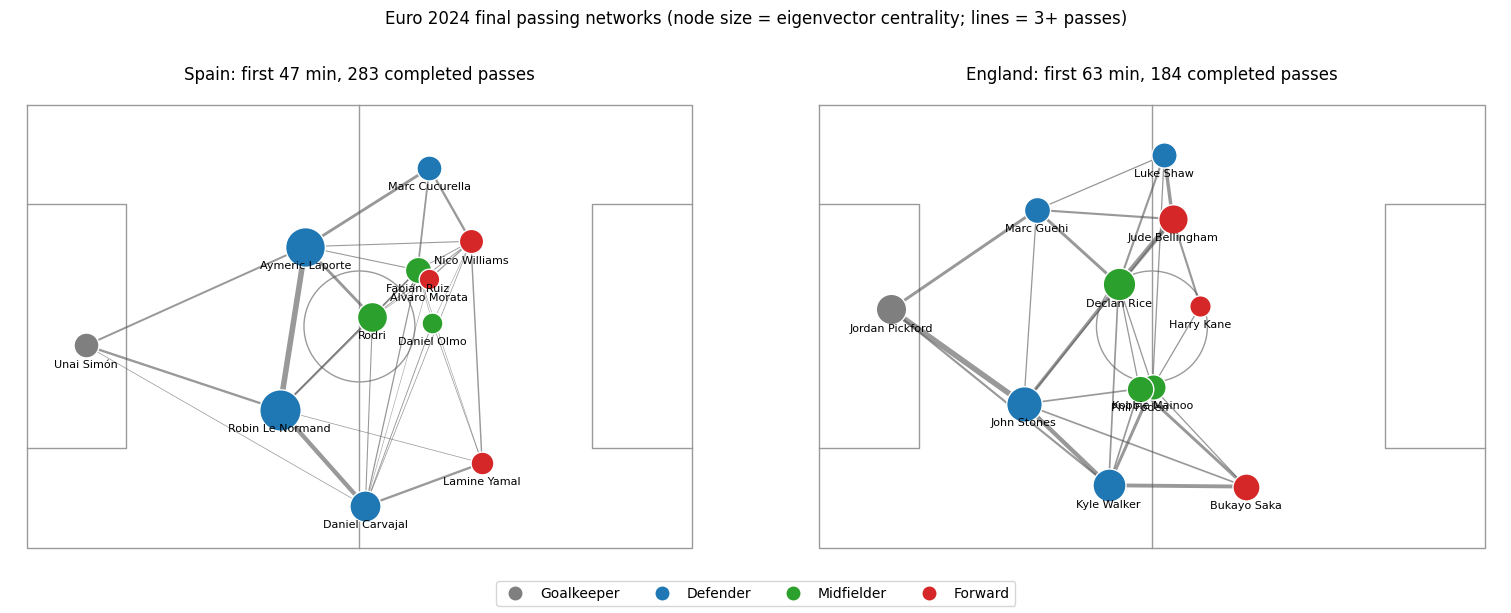

In [38]:
final_id = matches_df.iloc[-1]["match_id"]
final_ev = events[final_id]

def average_positions(ev, G):
    locs = {pid: [] for pid in G}
    for e in ev:
        if (e["type"]["name"] == "Pass" and e["team"]["name"] == G.graph["team"]
                and minute_of(e) < G.graph["window"] and "outcome" not in e["pass"]):
            if e["player"]["id"] in locs:
                locs[e["player"]["id"]].append(e["location"])
            rec = e["pass"].get("recipient", {}).get("id")
            if rec in locs:
                locs[rec].append(e["pass"]["end_location"])
    return {pid: np.mean(v, axis=0) if v else np.array([60, 40]) for pid, v in locs.items()}

def draw_pitch(ax):
    kw = dict(color="#9a9a9a", lw=1, zorder=0)
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], **kw); ax.plot([60, 60], [0, 80], **kw)
    ax.add_patch(plt.Circle((60, 40), 10, fill=False, **kw))
    for x0, x1 in [(0, 18), (120, 102)]:
        ax.plot([x0, x1, x1, x0], [18, 18, 62, 62], **kw)
    ax.set_xlim(-3, 123); ax.set_ylim(83, -3); ax.set_aspect("equal"); ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (key, G) in zip(axes, [(k, G) for k, G in networks.items() if k[0] == final_id]):
    draw_pitch(ax)
    pos = average_positions(final_ev, G)
    eig = nx.eigenvector_centrality_numpy(G, weight="weight")
    max_w = max(d["weight"] for *_, d in G.edges(data=True))
    for a, b, d in G.edges(data=True):
        if d["weight"] >= 3:
            ax.plot(*zip(pos[a], pos[b]), color="#555", lw=4 * d["weight"] / max_w, alpha=0.6, zorder=1)
    for pid, attrs in G.nodes(data=True):
        ax.scatter(*pos[pid], s=200 + 2500 * eig[pid] ** 2, color=COLORS[attrs["group"]],
                   edgecolor="white", zorder=2)
        ax.annotate(attrs["name"], pos[pid], xytext=(0, -16), textcoords="offset points",
                    ha="center", fontsize=8, zorder=3)
    ax.set_title(f"{key[1]}: first {G.graph['window']:.0f} min, {G.size(weight='weight'):.0f} completed passes")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=g, markersize=9) for g, c in COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4)
plt.suptitle("Euro 2024 final passing networks (node size = eigenvector centrality; lines = 3+ passes)", y=1.0)
plt.tight_layout(rect=(0, 0.05, 1, 0.95)); plt.show()

## 5. Comparing centrality across position groups
With four groups, I first test whether any group differs, using a 1 way ANOVA and its rank-based counterpart, Kruskal–Wallis. The rank-based test matters because degree centrality piles up at its maximum of 1.0.

In [39]:
MEASURES = ["degree", "pass_share", "eigenvector"]
display(cent.groupby("group", observed=True)[MEASURES].agg(["mean", "median", "std", "count"]))

rows = []
for m in MEASURES:
    groups = [g[m].values for _, g in cent.groupby("group", observed=True)]
    f, p_f = stats.f_oneway(*groups)
    h, p_h = stats.kruskal(*groups)
    rows.append({"measure": m, "ANOVA F": f, "p (ANOVA)": p_f, "Kruskal H": h, "p (Kruskal)": p_h})
omnibus = pd.DataFrame(rows).set_index("measure")
omnibus.style.format({"ANOVA F": "{:.1f}", "Kruskal H": "{:.1f}", "p (ANOVA)": "{:.1e}", "p (Kruskal)": "{:.1e}"})

degree                     pass_share                     eigenvector                    
             mean median    std count       mean median    std count        mean median    std count
group                                                                                               
Goalkeeper  0.681    0.7  0.154   100      0.106  0.101  0.044   100       0.181  0.167  0.084   100
Defender    0.846    0.9  0.133   435      0.218  0.214  0.067   435       0.332  0.334  0.106   435
Midfielder  0.904    0.9  0.110   332      0.206  0.205  0.068   332       0.307  0.314  0.106   332
Forward     0.788    0.8  0.139   233      0.114  0.110  0.048   233       0.166  0.155  0.083   233

,ANOVA F,p (ANOVA),Kruskal H,p (Kruskal)
measure,,,,
degree,89.2,1.2e-51,214.6,3.0e-46
pass_share,208.3,6.6e-107,426.3,4.5e-92
eigenvector,181.5,1.6e-95,368.2,1.7e-79


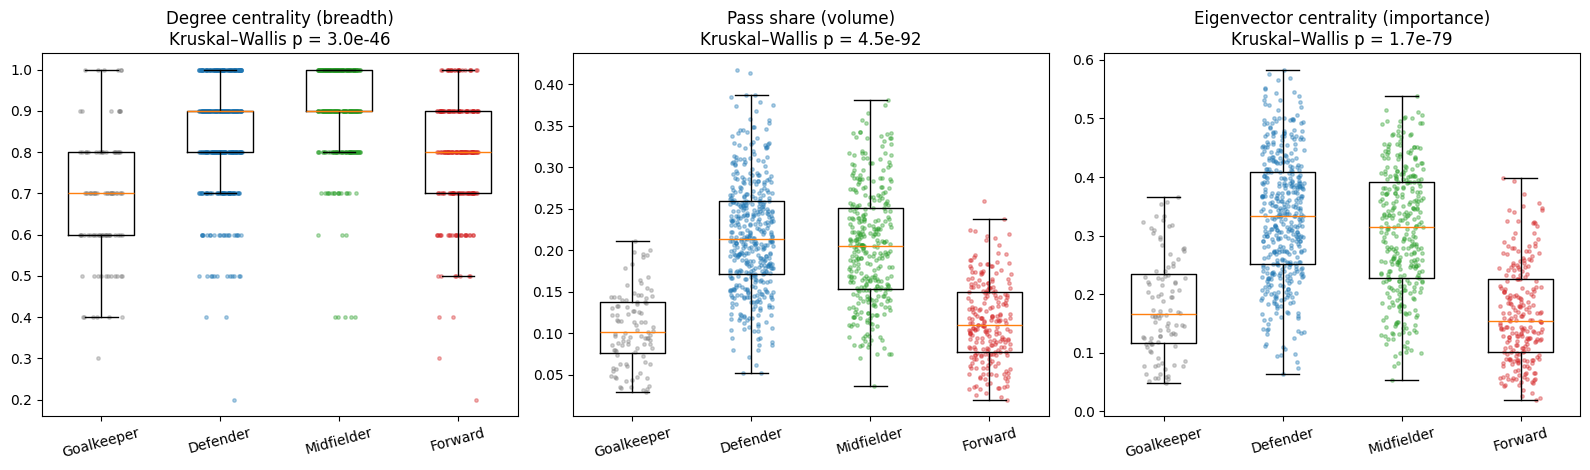

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
rng = np.random.default_rng(0)
titles = {"degree": "Degree centrality (breadth)", "pass_share": "Pass share (volume)",
          "eigenvector": "Eigenvector centrality (importance)"}
for ax, m in zip(axes, MEASURES):
    data = [cent.loc[cent.group == g, m] for g in ORDER]
    ax.boxplot(data, tick_labels=ORDER, widths=0.55, showfliers=False)
    for k, (g, vals) in enumerate(zip(ORDER, data), start=1):
        ax.scatter(k + rng.uniform(-0.18, 0.18, len(vals)), vals, s=6, alpha=0.35, color=COLORS[g])
    ax.set_title(f"{titles[m]}\nKruskal–Wallis p = {omnibus.loc[m, 'p (Kruskal)']:.1e}")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

### 5a. Pairwise comparisons
To find out which groups differ, I compare every pair with Welch's t-test, Mann–Whitney U and Cohen's d. With 6 pairs × 3 measures = 18 comparisons, I then apply a Bonferroni correction by multiplying each p-value by 18 to avoid false positives from running many tests.

The comparison that tests Hypothesis 1 directly is Midfielder vs Defender.

In [41]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled

pairs = [(a, b) for i, a in enumerate(ORDER) for b in ORDER[i + 1:]]
n_tests = len(pairs) * len(MEASURES)
rows = []
for m in MEASURES:
    for g1, g2 in pairs:
        a, b = cent.loc[cent.group == g1, m], cent.loc[cent.group == g2, m]
        t, p_t = stats.ttest_ind(a, b, equal_var=False)
        _, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"measure": m, "comparison": f"{g1} vs {g2}", f"mean 1": a.mean(), "mean 2": b.mean(),
                     "Welch t": t, "p (t, Bonferroni)": min(p_t * n_tests, 1),
                     "p (MWU, Bonferroni)": min(p_u * n_tests, 1), "Cohen's d": cohens_d(a, b)})
pairwise = pd.DataFrame(rows)
pairwise.style.format({"mean 1": "{:.3f}", "mean 2": "{:.3f}", "Welch t": "{:.2f}", "Cohen's d": "{:.2f}",
                       "p (t, Bonferroni)": "{:.1e}", "p (MWU, Bonferroni)": "{:.1e}"}).hide(axis="index")

measure,comparison,mean 1,mean 2,Welch t,"p (t, Bonferroni)","p (MWU, Bonferroni)",Cohen's d
degree,Goalkeeper vs Defender,0.681,0.846,-9.86,2.4e-16,2.1e-19,-1.20
degree,Goalkeeper vs Midfielder,0.681,0.904,-13.44,3.7e-25,9.2e-31,-1.83
degree,Goalkeeper vs Forward,0.681,0.788,-5.96,2.6e-07,2.2e-08,-0.74
degree,Defender vs Midfielder,0.846,0.904,-6.62,1.2e-09,4.7e-10,-0.47
degree,Defender vs Forward,0.846,0.788,5.23,4.7e-06,5.1e-07,0.43
degree,Midfielder vs Forward,0.904,0.788,10.64,2.4e-22,8.7e-26,0.95
pass_share,Goalkeeper vs Defender,0.106,0.218,-20.41,5.8e-51,5.3e-38,-1.77
pass_share,Goalkeeper vs Midfielder,0.106,0.206,-17.15,5.7e-43,9.4e-31,-1.57
pass_share,Goalkeeper vs Forward,0.106,0.114,-1.45,1.0e+00,1.0e+00,-0.17
pass_share,Defender vs Midfielder,0.218,0.206,2.44,2.7e-01,2.9e-01,0.18


### 5b. A closer look at defenders: center backs vs full backs
"Defender" mixes two different roles. Center backs start most attacks from deep, while full backs and wing backs push up the flanks or incorporate into the midfield almost playing as a midfielder. Splitting them shows where the defenders' centrality comes from.

,degree,pass_share,eigenvector
role,,,
Goalkeeper,0.681,0.106,0.181
Center back,0.860,0.242,0.373
Full/wing back,0.828,0.189,0.285
Midfielder,0.904,0.206,0.307
Forward,0.788,0.114,0.166


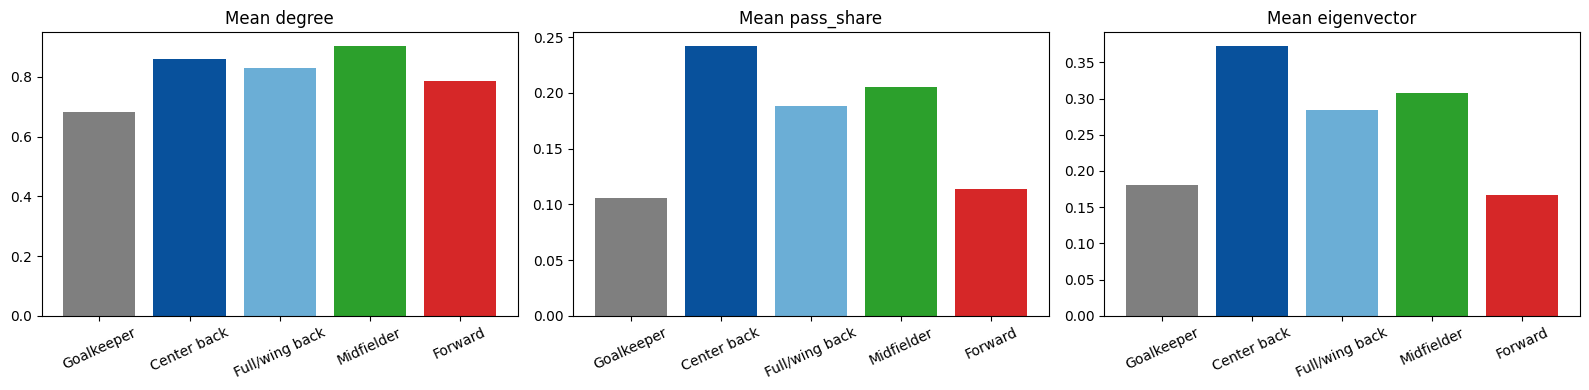

Eigenvector, center backs vs midfielders: 0.373 vs 0.307 (Welch t = 7.52, p = 2.4e-13, d = 0.63)


In [42]:
ROLE_ORDER = ["Goalkeeper", "Center back", "Full/wing back", "Midfielder", "Forward"]
by_role = cent.groupby("role")[MEASURES].mean().loc[ROLE_ORDER]
display(by_role)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
role_colors = ["#7f7f7f", "#08519c", "#6baed6", "#2ca02c", "#d62728"]
for ax, m in zip(axes, MEASURES):
    ax.bar(ROLE_ORDER, by_role[m], color=role_colors)
    ax.set_title(f"Mean {m}"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

cb = cent.loc[cent.role == "Center back", "eigenvector"]; mf = cent.loc[cent.role == "Midfielder", "eigenvector"]
t, p = stats.ttest_ind(cb, mf, equal_var=False)
print(f"Eigenvector, center backs vs midfielders: {cb.mean():.3f} vs {mf.mean():.3f} "
      f"(Welch t = {t:.2f}, p = {p:.1e}, d = {cohens_d(cb, mf):.2f})")

### 5c. Robustness check: one value per player
The same player appears in several matches, so the observations above are not fully independent. As a check, I average each player's centrality across all of their matches and rerun the group test with one value per player.

In [43]:
per_player = cent.groupby(["player", "group"], observed=True)[MEASURES].mean().reset_index()
print("Players per group:", per_player.group.value_counts().reindex(ORDER).to_dict())
rows = []
for m in MEASURES:
    groups = [g[m].values for _, g in per_player.groupby("group", observed=True)]
    h, p = stats.kruskal(*groups)
    means = per_player.groupby("group", observed=True)[m].mean()
    rows.append({"measure": m, "Kruskal H": h, "p": p, "highest group": means.idxmax(), **means.round(3).to_dict()})
pd.DataFrame(rows).set_index("measure")

Players per group: {'Goalkeeper': 28, 'Defender': 150, 'Midfielder': 126, 'Forward': 97}


,Kruskal H,p,highest group,Goalkeeper,Defender,Midfielder,Forward
measure,,,,,,,
degree,100.670,1.115e-21,Midfielder,0.672,0.835,0.888,0.787
pass_share,166.106,8.815e-36,Defender,0.108,0.212,0.197,0.115
eigenvector,146.170,1.766e-31,Defender,0.184,0.324,0.293,0.169
